transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantity            0
price_per_unit      0
cogs                0
total_sale          0
dtype: int64
(1997, 11)
Top 10 Customers by Sales:
     customer_id  total_sale
74            75      2000.0
75            55      2000.0
76            94      2000.0
77            47      2000.0
94            37      2000.0
97            18      2000.0
103           28      2000.0
106          138      2000.0
109           77      2000.0
112           81      2000.0


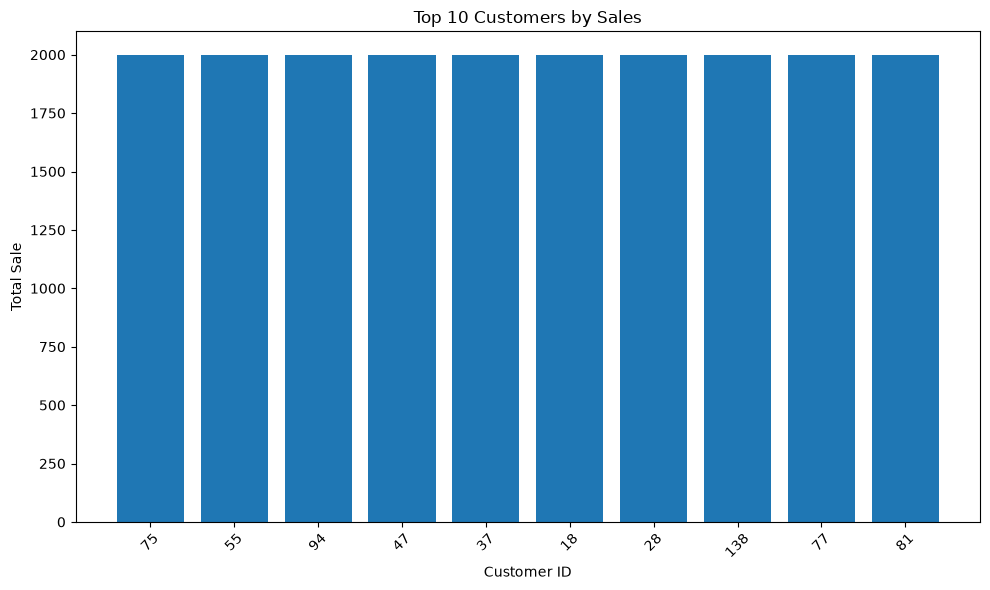

category
Electronics    313810.0
Clothing       311070.0
Beauty         286840.0
Name: total_sale, dtype: float64


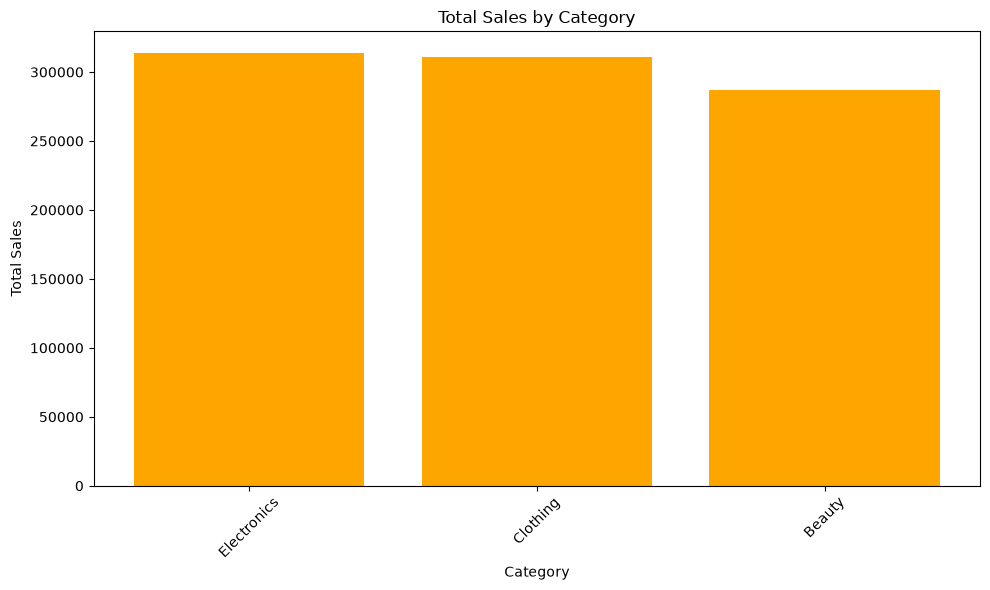

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"c:\Users\priya\Downloads\Retail_Sales.csv")
df = df.rename(columns={"quantiy": "quantity"})
df = df.drop_duplicates()
df["category"] = df["category"].fillna("Unknown")
df = df.dropna(subset=["price_per_unit", "cogs", "total_sale"])
df["price_per_unit"] = pd.to_numeric(df["price_per_unit"], errors="coerce")
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
df = df.dropna(subset=["price_per_unit", "sale_date"])

print(df.isnull().sum())
print(df.shape)
# Top 10 customers by total sale
top10 = df.nlargest(10, "total_sale")
print("Top 10 Customers by Sales:")
print(top10[["customer_id", "total_sale"]])

plt.figure(figsize=(10,6))
plt.bar(top10["customer_id"].astype(str), top10["total_sale"])
plt.xlabel("Customer ID")
plt.ylabel("Total Sale")
plt.title("Top 10 Customers by Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Total sales by category
category_sales = df.groupby("category")["total_sale"].sum().sort_values(ascending=False)
print(category_sales)

plt.figure(figsize=(10,6))
plt.bar(category_sales.index, category_sales.values, color="orange")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

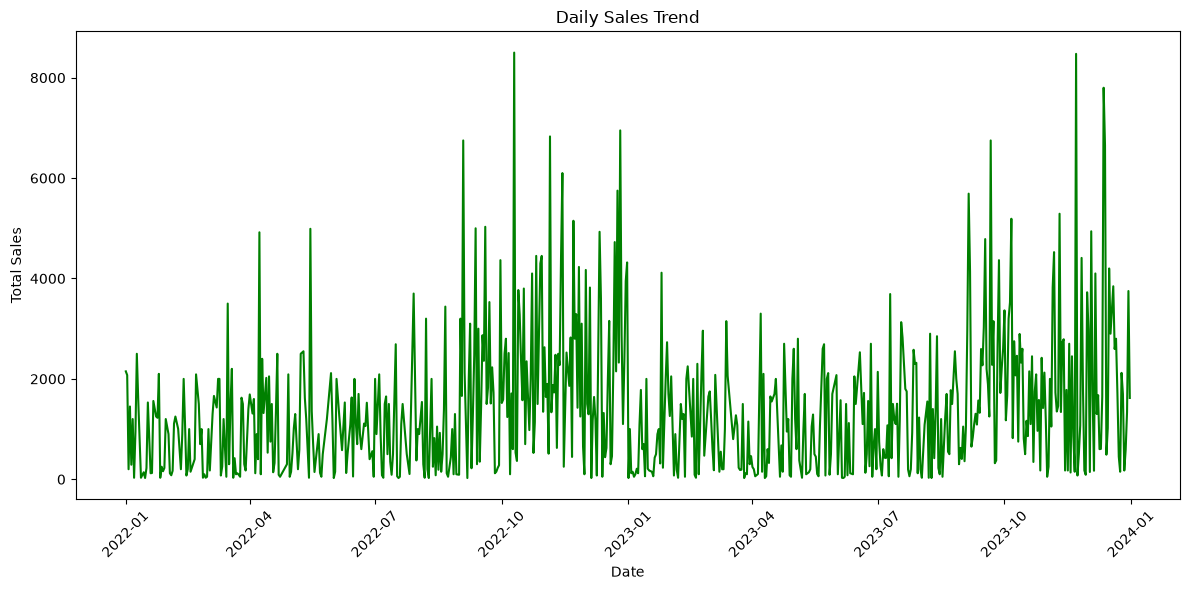

In [3]:
# Daily sales trend
daily_sales = df.groupby("sale_date")["total_sale"].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_sales.index, daily_sales.values, color="green")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

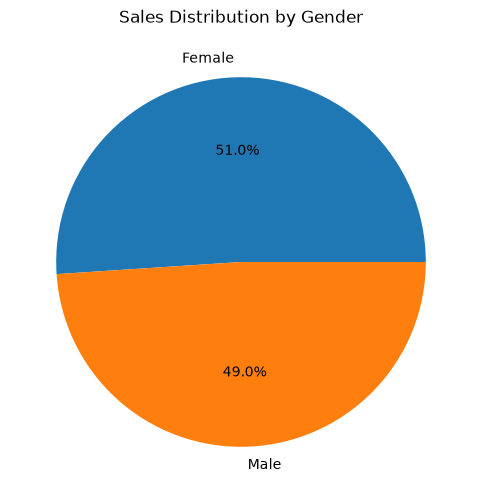

In [4]:
# Sales distribution by gender
gender_sales = df.groupby("gender")["total_sale"].sum()

plt.figure(figsize=(6,6))
plt.pie(gender_sales.values, labels=gender_sales.index, autopct="%1.1f%%")
plt.title("Sales Distribution by Gender")
plt.show()

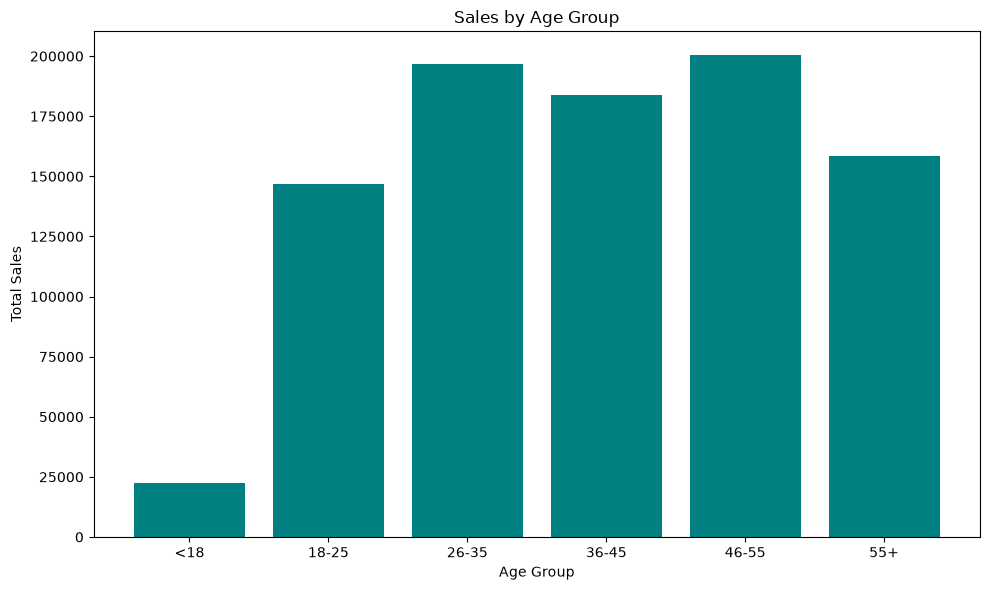

In [5]:
# Sales by age group
df["age_group"] = pd.cut(df["age"], bins=[0,18,25,35,45,55,100], 
                           labels=["<18","18-25","26-35","36-45","46-55","55+"])
age_sales = df.groupby("age_group")["total_sale"].sum()

plt.figure(figsize=(10,6))
plt.bar(age_sales.index.astype(str), age_sales.values, color="teal")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.title("Sales by Age Group")
plt.tight_layout()
plt.show()

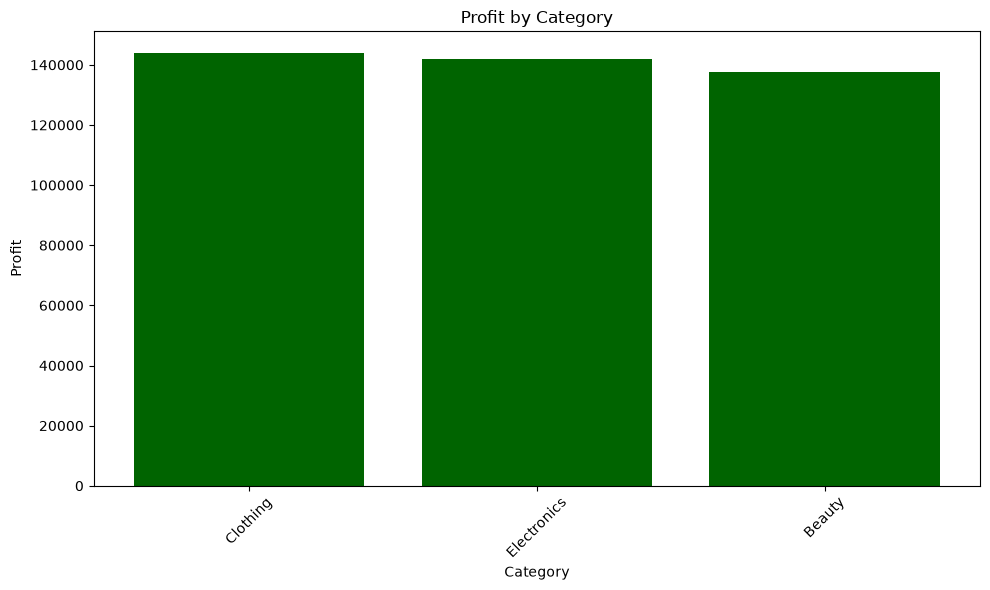

In [6]:
# Profit analysis by category
df["profit"] = df["total_sale"] - (df["cogs"] * df["quantity"])
profit_by_category = df.groupby("category")["profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(profit_by_category.index, profit_by_category.values, color="darkgreen")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Key insights summary
top_category = category_sales.idxmax()

print(f"Top performing category: {top_category}")
print(f"Highest single purchase: {top10.iloc[0]['total_sale']}")
print(f"Total revenue analyzed: {df['total_sale'].sum():,.2f}")

Top performing category: Electronics
Highest single purchase: 2000.0
Total revenue analyzed: 911,720.00
